In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit, prange

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation
import time

In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 500 * 10**5 # In timesteps of dt
gridpoints = 256 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean_multicomponent = 3E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
M = 1 # Units: (nm s)^-1
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84*np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

Da = vb * np.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

# Setup for AAAA vs ABBB System
B2aa = 2000 # Units: nm^3
B2bb = 2500 # Units: nm^3
B2ab = 2250 # Units: nm^3

Ka = 1.0E6 # Units: nm^5 
Kb = 1.0E6 # Units: nm^5 

In [ ]:
def get_phase_densities(T_target, valence, binodals_dir='binodals', tol=0.5):

    filepath = f'{binodals_dir}/f{valence:.1f}'
    
    # Loads the binodal data: columns are T, c1 (dilute), c2 (dense)
    data = np.loadtxt(filepath, comments='#')  # skip the header line
    
    T_vals = data[:, 0]
    c1_vals = data[:, 1]  # dilute phase densities
    c2_vals = data[:, 2]  # dense phase densities
    
    # Finds the index of the closest temperature (in case not exact)
    idx = np.argmin(np.abs(T_vals - T_target))
    
    if np.abs(T_vals[idx] - T_target) > tol:
        raise ValueError(
            f"No binodal data found within {tol} K of T={T_target}. "
            f"Closest available: T={T_vals[idx]:.2f} K"
        )
    
    rho_dilute = c1_vals[idx]
    rho_dense  = c2_vals[idx]
    
    return rho_dilute, rho_dense

rho_dilute, rho_dense = get_phase_densities(T, valence, binodals_dir='binodals', tol=0.5)

In [3]:
np.random.seed(1)
rhoAAAA = rho_mean_multicomponent * (1.0 + 0.1 * np.random.uniform(low=-1, high=1, size=gridpoints))
rhoAAAA = np.maximum(rhoAAAA, floor)

np.random.seed(2)
rhoABBB = rho_mean_multicomponent * (1.0 + 0.1 * np.random.uniform(low=-1, high=1, size=gridpoints))
rhoABBB = np.maximum(rhoABBB, floor)

rho_total_array_AAAA = rhoAAAA
rho_total_array_ABBB = rhoABBB

mass_history_multicomponent = []
time_history_multicomponent = []

@jit(nopython=True, parallel=True, cache=False)
def compute_step_two(rhoAAAA, rhoABBB):

    rhoAAAA_floored = np.maximum(rhoAAAA, floor)
    rhoABBB_floored = np.maximum(rhoABBB, floor)

    # A-end density: AAAA contributes 1 (of 4) per molecule fully, ABBB contributes 0.25 (1 of 4 ends)
    Ca = (rhoAAAA_floored + 0.25 * rhoABBB_floored) * valence * Da
    Xa = (-1.0 + np.sqrt(1.0 + 4.0 * Ca)) / (2.0 * Ca)

    # B-end density: only ABBB contributes, 0.75 (3 of 4 ends)
    Cb = 0.75 * rhoABBB_floored * valence * Db
    Xb = (-1.0 + np.sqrt(1.0 + 4.0 * Cb)) / (2.0 * Cb)

    laplacian_1d_rhoAAAA = (np.roll(rhoAAAA_floored, -1) - 2.0 * rhoAAAA_floored + np.roll(rhoAAAA_floored, 1)) * inv_dx2
    laplacian_1d_rhoABBB = (np.roll(rhoABBB_floored, -1) - 2.0 * rhoABBB_floored + np.roll(rhoABBB_floored, 1)) * inv_dx2

    beta_mu_total_AAAA = (2.0 * B2aa * rhoAAAA_floored + 2.0 * B2ab * rhoABBB_floored +
                           np.log(rhoAAAA_floored) +
                           valence * np.log(Xa) -
                           Ka * laplacian_1d_rhoAAAA)

    beta_mu_total_ABBB = (2.0 * B2ab * rhoAAAA_floored + 2.0 * B2bb * rhoABBB_floored +
                           np.log(rhoABBB_floored) +
                           (valence / 4.0) * (np.log(Xa) + 3.0 * np.log(Xb)) -
                           Kb * laplacian_1d_rhoABBB)

    rhoAAAA_step = dt * M * (np.roll(beta_mu_total_AAAA, -1) - 2.0 * beta_mu_total_AAAA + np.roll(beta_mu_total_AAAA, 1)) * inv_dx2
    rhoABBB_step = dt * M * (np.roll(beta_mu_total_ABBB, -1) - 2.0 * beta_mu_total_ABBB + np.roll(beta_mu_total_ABBB, 1)) * inv_dx2

    return rhoAAAA_step, rhoABBB_step, Xa, Xb

start_time = time.perf_counter()
for step in range(duration):
    rhoAAAA_step, rhoABBB_step, Xa, Xb = compute_step_two(rhoAAAA, rhoABBB)
    rhoAAAA += rhoAAAA_step
    rhoABBB += rhoABBB_step

    # Floor applied every step, not just at save interval

    if step % save_interval == 0:
        rho_total_array_AAAA = np.vstack((rho_total_array_AAAA, rhoAAAA))
        rho_total_array_ABBB = np.vstack((rho_total_array_ABBB, rhoABBB))

        rhoAAAA = np.maximum(rhoAAAA, floor)
        rhoABBB = np.maximum(rhoABBB, floor)

        total_mass = np.sum(rhoAAAA + rhoABBB)
        mass_history_multicomponent.append(total_mass)
        time_history_multicomponent.append(step * dt)

        time_elapsed = time.perf_counter() - start_time
        print(f"Progress: {(step/(save_interval))} out of {duration/(save_interval)} at {time_elapsed:1f} seconds")

Progress: 0.0 out of 500.0 at 1.687506 seconds
Progress: 1.0 out of 500.0 at 6.970033 seconds
Progress: 2.0 out of 500.0 at 12.285546 seconds
Progress: 3.0 out of 500.0 at 17.637972 seconds
Progress: 4.0 out of 500.0 at 22.922428 seconds
Progress: 5.0 out of 500.0 at 28.267221 seconds
Progress: 6.0 out of 500.0 at 33.832524 seconds
Progress: 7.0 out of 500.0 at 39.464742 seconds
Progress: 8.0 out of 500.0 at 44.806014 seconds
Progress: 9.0 out of 500.0 at 50.156068 seconds
Progress: 10.0 out of 500.0 at 55.487889 seconds
Progress: 11.0 out of 500.0 at 60.883881 seconds
Progress: 12.0 out of 500.0 at 66.253548 seconds
Progress: 13.0 out of 500.0 at 71.586478 seconds
Progress: 14.0 out of 500.0 at 76.926360 seconds
Progress: 15.0 out of 500.0 at 82.320307 seconds
Progress: 16.0 out of 500.0 at 87.658855 seconds
Progress: 17.0 out of 500.0 at 93.037353 seconds
Progress: 18.0 out of 500.0 at 98.384405 seconds
Progress: 19.0 out of 500.0 at 103.700736 seconds
Progress: 20.0 out of 500.0 at 

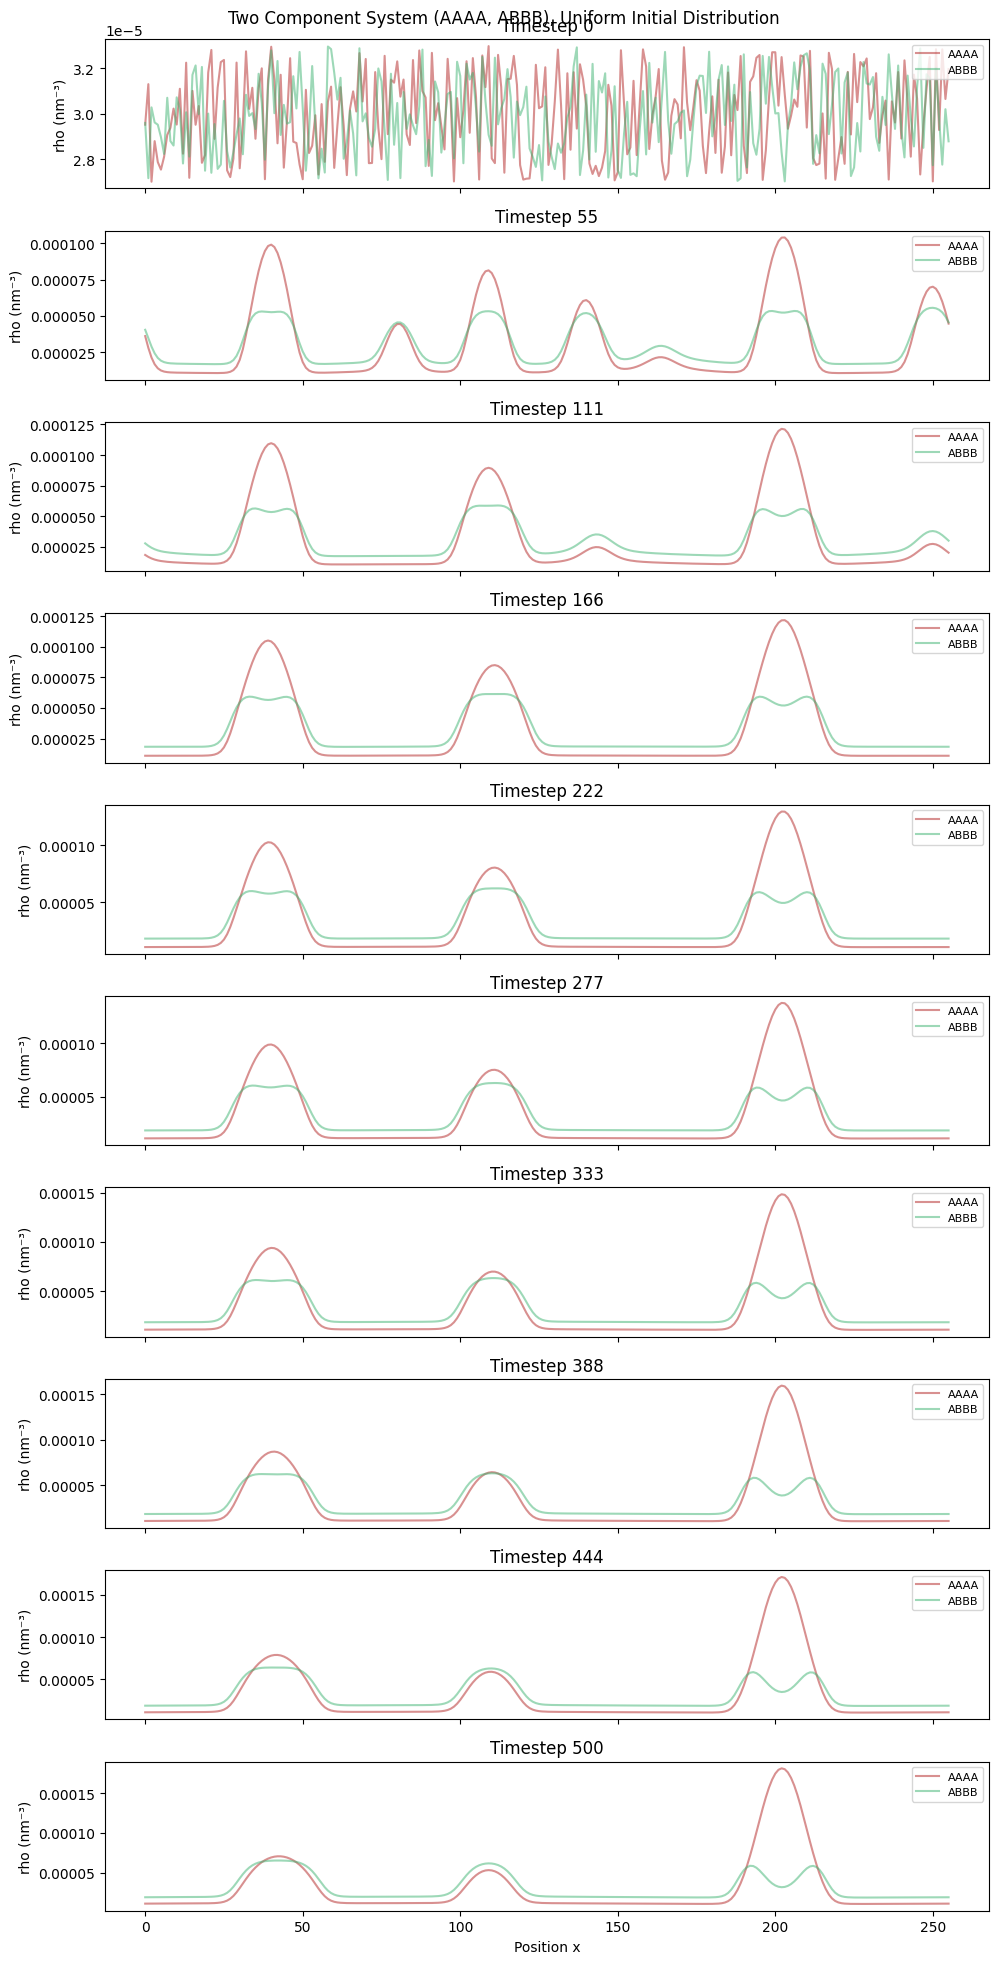

In [4]:
# Initializes x-axis values
x = np.arange(rho_total_array_AAAA.shape[1])

# Picks evenly spaced timesteps to graph
n_snapshots = 10
timesteps = np.linspace(0, rho_total_array_AAAA.shape[0]-1, n_snapshots, dtype=int)

# Makes subplots
fig, axes = plt.subplots(n_snapshots, 1, figsize=(10, 2*n_snapshots), sharex=True)
colors = {"AAAA":"firebrick", "ABBB":"mediumseagreen"}
for i, t in enumerate(timesteps):
    ax = axes[i]
    ax.plot(x, rho_total_array_AAAA[t], color=colors["AAAA"], label="AAAA", alpha=0.5)
    ax.plot(x, rho_total_array_ABBB[t], color=colors["ABBB"], label="ABBB", alpha=0.5)
    ax.set_ylabel("rho (nm⁻³)")
    ax.set_title(f"Timestep {t}")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Two Component System (AAAA, ABBB), Uniform Initial Distribution")
axes[-1].set_xlabel("Position x")
plt.tight_layout()
plt.show()

In [5]:
#Uses free energy formula from above
def calc_free_energy_multicomponent(rho_total_array_AAAA, rho_total_array_BBBB, rho_total_array_AABB, Xa, Xb, v0=1):
    '''
    Finds free energy of a multi-component system using F = integral_V [ f({rho_i}) + K/2 sum_i (gradient rho)^2 ] dV

    Using f_ref = rho_tot * log(v_0 * rho_tot) - rho_tot + B2 * rho_tot^2 + sum_i [rho_i * log(rho_i/rho_tot)]

    Note that the final term IS included in this!

    Using f_b = rho_A * valence * (log(Xa) + (1-Xa)/2) + rho_B * valence * (log(Xb) + (1-Xb)/2) 
              + rho_AB * valence/2 * (log(Xa) + (1-Xa)/2) + rho_AB * valence/2 * (log(Xb) + (1-Xb)/2)
    
    For AAAA, BBBB, and AABB
    '''

    # Calculates the total density
    rho_tot = rho_total_array_AAAA + rho_total_array_BBBB + rho_total_array_AABB
    
    # To prevent error
    rho_A_floored = np.maximum(rho_total_array_AAAA, floor)
    rho_B_floored = np.maximum(rho_total_array_BBBB, floor)
    rho_AB_floored = np.maximum(rho_total_array_AABB, floor)
    rho_tot_floored = np.maximum(rho_tot, floor)

    # Finds f_ref including the final term
    f_ref = (rho_tot_floored * np.log(v0 * rho_tot_floored) - rho_tot_floored + B2 * rho_tot_floored**2 +
            rho_A_floored * np.log(rho_A_floored / rho_tot_floored) +  rho_B_floored * np.log(rho_B_floored / rho_tot_floored) + rho_AB_floored * np.log(rho_AB_floored / rho_tot_floored))

    # Finds f_b for each component and adds
    f_b = (rho_A_floored * 4 * (np.log(Xa) + (1-Xa)/2) +
            rho_B_floored * 4 * (np.log(Xb) + (1-Xb)/2) +
            rho_AB_floored * 2 * (np.log(Xa) + (1-Xa)/2) + rho_AB_floored * 2 * (np.log(Xb) + (1-Xb)/2))
    
    # Finds the free energy at each point (f{rho_i})
    f_local = f_ref + f_b
    
    # Calculates the gradient term K/2 * sum_i (gradient rho_i)^2
    f_gradient = 0.5 * K * ((np.gradient(rho_A_floored, dx))**2 + 
                           (np.gradient(rho_B_floored, dx))**2 + 
                           (np.gradient(rho_AB_floored, dx))**2)
    
    # Total free energy density
    f_total = f_local + f_gradient
    
    # Integrate over volume in 1D (multiply by dx and sum)
    F_total = np.trapz(f_total, dx=dx)
    
    return F_total


#Takes floored value for densities and finds area of interface for final system
rho_A_floored = np.maximum(rhoAAAA, floor)
rho_B_floored = np.maximum(rhoBBBB, floor)
rho_AB_floored = np.maximum(rhoAABB, floor)
rho_tot = rhoAAAA + rhoBBBB + rhoAABB
rho_tot_floored = np.maximum(rho_tot, floor)
A = dx ** 2

# Extracts dilute/dense phase densities for each component and creates homogeneous systems
rho_A_dilute = np.min(rho_A_floored) 
rho_A_dense = np.max(rho_A_floored)
rho_B_dilute = np.min(rho_B_floored)
rho_B_dense = np.max(rho_B_floored)
rho_AB_dilute = np.min(rho_AB_floored)
rho_AB_dense = np.max(rho_AB_floored)

rho_A_dilute_system = np.full(gridpoints, rho_A_dilute)
rho_A_dense_system = np.full(gridpoints, rho_A_dense)
rho_B_dilute_system = np.full(gridpoints, rho_B_dilute)
rho_B_dense_system = np.full(gridpoints, rho_B_dense)
rho_AB_dilute_system = np.full(gridpoints, rho_AB_dilute)
rho_AB_dense_system = np.full(gridpoints, rho_AB_dense)

# Finds Xa and Xb for dilute, dense, and coex systems

# For coexisting system
Xa_final_coex = np.maximum(Xa, floor)
Xb_final_coex = np.maximum(Xb, floor) 

# For dilute system
CaDa_dilute = 4*rho_A_dilute_system*Da + 2*rho_AB_dilute_system*Da
CaDa_dilute_floored = np.maximum(CaDa_dilute, floor)
Xa_final_dilute = (-1 + np.sqrt(1 + 4 * CaDa_dilute_floored)) / (2 * CaDa_dilute_floored)

CaDb_dilute = 4*rho_B_dilute_system*Db + 2*rho_AB_dilute_system*Db
CaDb_dilute_floored = np.maximum(CaDb_dilute, floor)
Xb_final_dilute = (-1 + np.sqrt(1 + 4 * CaDb_dilute_floored)) / (2 * CaDb_dilute_floored)


# For dense system
CaDa_dense = 4*rho_A_dense_system*Da + 2*rho_AB_dense_system*Da
CaDa_dense_floored = np.maximum(CaDa_dense, floor)
Xa_final_dense = (-1 + np.sqrt(1 + 4 * CaDa_dense_floored)) / (2 * CaDa_dense_floored)

CaDb_dense = 4*rho_B_dense_system*Db + 2*rho_AB_dense_system*Db
CaDb_dense_floored = np.maximum(CaDb_dense, floor)
Xb_final_dense = (-1 + np.sqrt(1 + 4 * CaDb_dense_floored)) / (2 * CaDb_dense_floored)

# Finds free energy of dilute, dense, and coexisting systems
F_dilute = calc_free_energy_multicomponent(rho_A_dilute_system, rho_B_dilute_system, rho_AB_dilute_system,
                                         Xa_final_dilute, Xb_final_dilute)

F_dense = calc_free_energy_multicomponent(rho_A_dense_system, rho_B_dense_system, rho_AB_dense_system,
                                        Xa_final_dense, Xb_final_dense)

F_coex = calc_free_energy_multicomponent(rho_A_floored, rho_B_floored, rho_AB_floored,
                                       Xa_final_coex, Xb_final_coex)

# Finds number of interfaces, assuming a proper phase separated final rho using total density
threshold = (np.min(rho_tot_floored) + np.max(rho_tot_floored)) / 2
interface_locations = np.where(np.diff((rho_tot > threshold).astype(int)) != 0) #Assigns dilute/dense, then finds changes between them
interface_count = len(interface_locations[0]) #total number of interfaces (should be 2)

# surface_tension = (F_coex - F_dilute - F_dense) / (interface_count * A)  NEEDS TO BE FIXED- FRACTIONAL SYSTEM
# print(f"The surface tension is {surface_tension:.6e} for T = {T} in a 1D system with {interface_count} interfaces and 3 components (AAAA, BBBB, and AABB with Cx = {Cx}) initialized with a uniform distribution")

NameError: name 'rhoBBBB' is not defined

In [ ]:
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Spatial grid
x = np.linspace(0, gridpoints, gridpoints)

# Time sampling strategy
early = np.logspace(0, np.log10(20), 300, dtype=int)
late = np.logspace(np.log10(20), np.log10(len(rho_total_array_AAAA)-1), 100, dtype=int)
timesteps = np.unique(np.concatenate([early, late]))

# Prepare data arrays
data_AAAA = [rho_total_array_AAAA[t] for t in timesteps]
data_BBBB = [rho_total_array_BBBB[t] for t in timesteps]
data_AABB = [rho_total_array_AABB[t] for t in timesteps]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

line_AAAA, = ax.plot(x, data_AAAA[0], color="firebrick", label="AAAA", alpha = 0.6)
line_BBBB, = ax.plot(x, data_BBBB[0], color="mediumseagreen", label="BBBB", alpha = 0.6)
line_AABB, = ax.plot(x, data_AABB[0], color="darkblue", label="AABB", alpha = 0.6)

ax.set_xlim(x[0], x[-1])
ax.set_ylim(
    min(np.min(data_AAAA), np.min(data_BBBB), np.min(data_AABB)),
    max(np.max(data_AAAA), np.max(data_BBBB), np.max(data_AABB))
)
ax.set_xlabel("Position")
ax.set_ylabel("Density (nm⁻³)")
ax.legend(loc="upper right")

# Animation update function
def update(frame):
    line_AAAA.set_ydata(data_AAAA[frame])
    line_BBBB.set_ydata(data_BBBB[frame])
    line_AABB.set_ydata(data_AABB[frame])
    ax.set_title(f'Time step: {timesteps[frame]}')
    return line_AAAA, line_BBBB, line_AABB

# Animate
ani = FuncAnimation(fig, update, frames=len(timesteps), interval=200, blit=True)
ani.save("multicomponent_densities.gif", writer=PillowWriter(fps=7))